# Synthetic-100 regression: MiSTIC member count and sklearn references

This is the regression analogue of the synthetic classification benchmark. It
uses 500 observations, 100 predictors, 10 directly informative features, 10
correlated redundant signal features, and 80 noise features. A fixed 25% blind
set is removed before scaling, feature selection, or tuning.

MiSTIC uses forward-knee selection with `rank_weight=0.90`,
`addition_factor=0.1`, `max_features=20`, separate member features and
parameters, no per-step tuning, final knee retuning, and 5, 10, or 20 members.
All conditions use ten seeded inner shuffle-split constructions and the same
blind observations.

References mirror the classification notebook: RBF-SVR on all features,
linear-SVR RFE to 20 features, RBF-SVR on each ensemble's knee-ranked unified
features, and an oracle RBF-SVR using the 20 known signal features.


In [1]:
import time
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import pearsonr
from sklearn.datasets import make_regression
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, ShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents]
                 if (path / "mistic" / "svmSet.py").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svr, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)


Matplotlib is building the font cache; this may take a moment.


In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))
DATA_SEED = 2026
BLIND_SET_SEED = 42
INNER_SEEDS = list(range(10))
MEMBER_COUNTS = [5, 10, 20]
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
RANK_WEIGHT = 0.90
MAX_FEATURES = 20
ADDITION_FACTOR = 0.1
RFE_FEATURE_COUNT = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]
EPSILON_VALUES = [0.05, 0.1, 0.2]

# Start with 10 informative plus 80 independent noise predictors. Insert 10
# noisy linear combinations of the informative block as redundant signal.
base_X, y_values, coefficients = make_regression(
    n_samples=N_SAMPLES, n_features=90, n_informative=N_INFORMATIVE,
    noise=20.0, shuffle=False, random_state=DATA_SEED, coef=True,
)
rng = np.random.default_rng(DATA_SEED)
mixing = rng.normal(size=(N_INFORMATIVE, N_REDUNDANT))
redundant = base_X[:, :N_INFORMATIVE] @ mixing
redundant += rng.normal(scale=0.10 * redundant.std(axis=0), size=redundant.shape)
X_values = np.column_stack([base_X[:, :N_INFORMATIVE], redundant, base_X[:, N_INFORMATIVE:]])
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="target")

X_train, X_blind, y_train_raw, y_blind_raw = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=BLIND_SET_SEED,
)
y_mean = y_train_raw.mean()
y_scale = y_train_raw.std(ddof=0)
y_train = (y_train_raw - y_mean) / y_scale
y_blind = (y_blind_raw - y_mean) / y_scale
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")
print(f"Training target mean={y_train.mean():.3g}, SD={y_train.std(ddof=0):.3g}")


Training rows: 375; fixed blind rows: 125
Training target mean=0, SD=1


In [3]:
def metric_row(y_true, predictions):
    r = pearsonr(y_true, predictions).statistic
    return {
        "r2": r2_score(y_true, predictions),
        "rmse": root_mean_squared_error(y_true, predictions),
        "mae": mean_absolute_error(y_true, predictions),
        "pearson_r2": r * r,
    }


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    return signal_count / len(SIGNAL_FEATURES), signal_count / len(features)


def sklearn_grid(seed):
    return GridSearchCV(
        Pipeline([("scale", StandardScaler()), ("svr", SVR(kernel="rbf"))]),
        {"svr__C": C_VALUES, "svr__gamma": GAMMA_VALUES,
         "svr__epsilon": EPSILON_VALUES},
        scoring="r2", cv=KFold(n_splits=4, shuffle=True, random_state=seed),
        n_jobs=-1, refit=True,
    )


def fit_sklearn(features, seed):
    features = np.asarray(features, dtype=int)
    return sklearn_grid(seed).fit(X_train.iloc[:, features], y_train)


def fit_mistic(seed, num_models):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(X_scaled, np.asarray(y_train), num_feature_medoids=20,
                   ensemble_validation_size=0.0)
    splitter = ShuffleSplit(n_splits=num_models,
                            test_size=INNER_VALIDATION_SIZE,
                            random_state=seed)
    generated = list(splitter.split(X_scaled, y_train))
    splits.train = [train for train, _ in generated]
    splits.test = [test for _, test in generated]
    splits.type = "regression_shuffle_split"
    ensemble = svmSet(
        SVR(kernel="precomputed"), splits,
        score_method=score_svr(weight=0.0).score,
        kernel=kernelWrapper(type="rbf"),
        separate_feature_sets=True, separate_parameters=True,
    )
    grid = [
        paramSet(model={"C": c, "epsilon": epsilon}, kernel={"gamma": gamma})
        for c in C_VALUES for gamma in GAMMA_VALUES for epsilon in EPSILON_VALUES
    ]
    ensemble.greedy_forward_selection(
        addition_factor=ADDITION_FACTOR, max_features=MAX_FEATURES,
        parameter_grid=grid,
        feature_ranker=combined_rank(weight=RANK_WEIGHT).compute,
        set_for_rank="sample", tune_models_each_step=False,
        post_find_knee=True,
    )
    return scaler, ensemble, ensemble.find_knee(metric="score")


def ranked_unified_features(ensemble, limit):
    unified = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([f for f in ensemble.unified_sorted_features if f in unified], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def sklearn_row(method, features, seed, associated_members=0):
    features = np.asarray(features, dtype=int)
    model = fit_sklearn(features, seed)
    predictions = model.predict(X_blind.iloc[:, features])
    recall, precision = recovery(features)
    return {
        "seed": seed, "method": method, "num_models": 1,
        "associated_mistic_members": associated_members,
        "knee_feature_count": np.nan, "mean_member_features": np.nan,
        "num_unified_features": len(features),
        "top20_signal_recall": recall, "top20_signal_precision": precision,
        "member_disagreement": 0.0, "cv_best_score": model.best_score_,
        **metric_row(y_blind, predictions),
    }


## Run the ten-seed paired comparison

The all-feature, RFE, and oracle references do not depend on MiSTIC member
count, so each is fitted once per seed. The unified reference is fitted
separately for every member-count/seed combination because its selected feature
identities are produced by that ensemble.


In [4]:
rows = []
all_features = np.arange(N_FEATURES)
oracle_features = np.arange(N_INFORMATIVE + N_REDUNDANT)
selector_scaler = StandardScaler().fit(X_train)
rfe = RFE(
    estimator=SVR(kernel="linear", C=1.0, epsilon=0.1),
    n_features_to_select=RFE_FEATURE_COUNT, step=0.1,
).fit(selector_scaler.transform(X_train), y_train)
rfe_features = np.flatnonzero(rfe.support_)

for seed in INNER_SEEDS:
    rows.append(sklearn_row("sklearn SVR: all 100 features", all_features, seed))
    rows.append(sklearn_row("sklearn SVR: linear-SVR RFE (20)", rfe_features, seed))
    rows.append(sklearn_row("sklearn SVR oracle: known signal (20)", oracle_features, seed))

for num_models in MEMBER_COUNTS:
    for seed in INNER_SEEDS:
        started = time.perf_counter()
        scaler, ensemble, knee_count = fit_mistic(seed, num_models)
        X_blind_scaled = scaler.transform(X_blind)
        predictions = ensemble.predict(X_blind_scaled)
        top20 = ranked_unified_features(ensemble, 20)
        unified_reference_features = ranked_unified_features(ensemble, knee_count)
        recall, precision = recovery(top20)
        selected_counts = np.asarray([len(f) for f in ensemble.features])
        member_predictions = np.column_stack([
            ensemble.predict(X_blind_scaled, model_index=i)
            for i in range(num_models)
        ])
        residuals = np.asarray(y_blind)[:, None] - member_predictions
        residual_correlations = [
            abs(np.corrcoef(residuals[:, i], residuals[:, j])[0, 1])
            for i in range(num_models) for j in range(i + 1, num_models)
        ]
        rows.append({
            "seed": seed,
            "method": f"MiSTIC SVR forward-knee ({num_models} members)",
            "num_models": num_models, "associated_mistic_members": num_models,
            "knee_feature_count": knee_count,
            "mean_member_features": selected_counts.mean(),
            "num_unified_features": len(ensemble.unified_features),
            "top20_signal_recall": recall, "top20_signal_precision": precision,
            "member_disagreement": 1 - np.mean(residual_correlations),
            "cv_best_score": np.nan,
            **metric_row(y_blind, predictions),
        })
        rows.append(sklearn_row(
            f"sklearn SVR: knee-ranked unified ({num_models}-member source)",
            unified_reference_features, seed, associated_members=num_models,
        ))
        print(f"members={num_models}, seed={seed}, knee={knee_count}, "
              f"elapsed={time.perf_counter() - started:.1f}s")

results = pd.DataFrame(rows)
results_path = repo_root / "validation/Synthetic100_regression_member_count_10seeds_results.csv"
results.to_csv(results_path, index=False)
results


Number of Features: 1, Score: 0.104


Number of Features: 10, Score: 0.630


Number of Features: 19, Score: 0.674


Number of Features: 20, Score: 0.669
Number of Features: 100, Score: 0.230


members=5, seed=0, knee=10, elapsed=8.2s


...

Number of Features: 10, Score: 0.689


Number of Features: 19, Score: 0.708


Number of Features: 20, Score: 0.703
Number of Features: 100, Score: 0.377


members=20, seed=9, knee=10, elapsed=28.0s


,seed,method,num_models,associated_mistic_members,knee_feature_count,mean_member_features,num_unified_features,top20_signal_recall,top20_signal_precision,member_disagreement,cv_best_score,r2,rmse,mae,pearson_r2
0,0,sklearn SVR: all 100 features,1,0,NaN,NaN,100,1.00,0.20,0.000000,0.961152,0.962747,0.165401,0.136120,0.965058
1,0,sklearn SVR: linear-SVR RFE (20),1,0,NaN,NaN,20,0.75,0.75,0.000000,0.980585,0.971209,0.145408,0.112661,0.971349
2,0,sklearn SVR oracle: known signal (20),1,0,NaN,NaN,20,1.00,1.00,0.000000,0.979331,0.973354,0.139885,0.110659,0.973494
3,1,sklearn SVR: all 100 features,1,0,NaN,NaN,100,1.00,0.20,0.000000,0.961859,0.962747,0.165401,0.136120,0.965058
4,1,sklearn SVR: linear-SVR RFE (20),1,0,NaN,NaN,20,0.75,0.75,0.000000,0.980489,0.971209,0.145408,0.112661,0.971349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,7,sklearn SVR: knee-ranked unified (20-member so...,1,20,NaN,NaN,10,0.50,1.00,0.000000,0.975194,0.967037,0.155586,0.120448,0.967183
86,8,MiSTIC SVR forward-knee (20 members),20,20,10.0,10.0,22,0.75,0.75,0.307057,NaN,0.941873,0.206608,0.165987,0.942760
87,8,sklearn SVR: knee-ranked unified (20-member so...,1,20,NaN,NaN,10,0.50,1.00,0.000000,0.952305,0.929085,0.228206,0.179444,0.929212
88,9,MiSTIC SVR forward-knee (20 members),20,20,10.0,10.0,21,0.75,0.75,0.286940,NaN,0.951182,0.189342,0.151723,0.951515


In [5]:
metrics = ["r2", "rmse", "mae", "pearson_r2", "knee_feature_count",
           "mean_member_features", "num_unified_features", "top20_signal_recall",
           "top20_signal_precision", "member_disagreement"]
summary = results.groupby("method")[metrics].agg(["mean", "std"])
summary.round(4)


r2            rmse  \
                                                      mean     std    mean   
method                                                                       
MiSTIC SVR forward-knee (10 members)                0.9478  0.0143  0.1938   
MiSTIC SVR forward-knee (20 members)                0.9451  0.0074  0.2004   
MiSTIC SVR forward-knee (5 members)                 0.9483  0.0156  0.1926   
sklearn SVR oracle: known signal (20)               0.9734  0.0000  0.1399   
sklearn SVR: all 100 features                       0.9627  0.0000  0.1654   
sklearn SVR: knee-ranked unified (10-member sou...  0.9443  0.0222  0.1982   
sklearn SVR: knee-ranked unified (20-member sou...  0.9365  0.0161  0.2140   
sklearn SVR: knee-ranked unified (5-member source)  0.9397  0.0193  0.2074   
sklearn SVR: linear-SVR RFE (20)                    0.9712  0.0000  0.1454   

                                                               mae          \
                                                       std    mean     std   
method                                                                       
MiSTIC SVR forward-knee (10 members)                0.0292  0.1549  0.0240   
MiSTIC SVR forward-knee (20 members)                0.0134  0.1607  0.0114   
MiSTIC SVR forward-knee (5 members)                 0.0311  0.1529  0.0250   
sklearn SVR oracle: known signal (20)               0.0000  0.1107  0.0000   
sklearn SVR: all 100 features                       0.0000  0.1361  0.0000   
sklearn SVR: knee-ranked unified (10-member sou...  0.0428  0.1561  0.0339   
sklearn SVR: knee-ranked unified (20-member sou...  0.0308  0.1680  0.0251   
sklearn SVR: knee-ranked unified (5-member source)  0.0374  0.1635  0.0297   
sklearn SVR: linear-SVR RFE (20)                    0.0000  0.1127  0.0002   

                                                   pearson_r2          \
                                                         mean     std   
method                                                                  
MiSTIC SVR forward-knee (10 members)                   0.9485  0.0143   
MiSTIC SVR forward-knee (20 members)                   0.9457  0.0075   
MiSTIC SVR forward-knee (5 members)                    0.9489  0.0155   
sklearn SVR oracle: known signal (20)                  0.9735  0.0000   
sklearn SVR: all 100 features                          0.9651  0.0000   
sklearn SVR: knee-ranked unified (10-member sou...     0.9446  0.0220   
sklearn SVR: knee-ranked unified (20-member sou...     0.9366  0.0161   
sklearn SVR: knee-ranked unified (5-member source)     0.9400  0.0191   
sklearn SVR: linear-SVR RFE (20)                       0.9713  0.0000   

                                                   knee_feature_count          \
                                                                 mean     std   
method                                                                          
MiSTIC SVR forward-knee (10 members)                             11.8  3.7947   
MiSTIC SVR forward-knee (20 members)                             10.0  0.0000   
MiSTIC SVR forward-knee (5 members)                              11.8  3.7947   
sklearn SVR oracle: known signal (20)                             NaN     NaN   
sklearn SVR: all 100 features                                     NaN     NaN   
sklearn SVR: knee-ranked unified (10-member sou...                NaN     NaN   
sklearn SVR: knee-ranked unified (20-member sou...                NaN     NaN   
sklearn SVR: knee-ranked unified (5-member source)                NaN     NaN   
sklearn SVR: linear-SVR RFE (20)                                  NaN     NaN   

                                                   mean_member_features  \
                                                                   mean   
method                                                                    
MiSTIC SVR forward-knee (10 members)                               11.8   
MiSTIC SVR forward-knee (20 memb

In [6]:
baseline = results.query("method == 'MiSTIC SVR forward-knee (5 members)'").set_index("seed")
paired_rows = []
for count in [10, 20]:
    candidate_method = f"MiSTIC SVR forward-knee ({count} members)"
    candidate = results.query("method == @candidate_method").set_index("seed")
    for metric in ["r2", "rmse", "mae", "pearson_r2"]:
        improvement = candidate[metric] - baseline[metric]
        if metric in ["rmse", "mae"]:
            improvement = -improvement
        paired_rows.append({
            "comparison": f"{count} minus 5 members", "metric": metric,
            "mean_improvement": improvement.mean(),
            "std_improvement": improvement.std(ddof=1),
            "larger_wins": int((improvement > 0).sum()),
            "ties": int((improvement == 0).sum()),
            "larger_losses": int((improvement < 0).sum()),
        })
paired = pd.DataFrame(paired_rows)
paired.round(4)


,comparison,metric,mean_improvement,std_improvement,larger_wins,ties,larger_losses
0,10 minus 5 members,r2,-0.0005,0.0161,3,0,7
1,10 minus 5 members,rmse,-0.0012,0.0323,3,0,7
2,10 minus 5 members,mae,-0.0020,0.0255,3,0,7
3,10 minus 5 members,pearson_r2,-0.0004,0.0162,3,0,7
4,20 minus 5 members,r2,-0.0032,0.0134,4,0,6
5,20 minus 5 members,rmse,-0.0078,0.0270,4,0,6
6,20 minus 5 members,mae,-0.0077,0.0215,4,0,6
7,20 minus 5 members,pearson_r2,-0.0031,0.0133,4,0,6


/var/folders/q_/4g9fzlq94y3d38pwjs5rt9f40000gn/T/ipykernel_73547/1576181304.py:13: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=plot_data, y="method", x="r2", order=order,


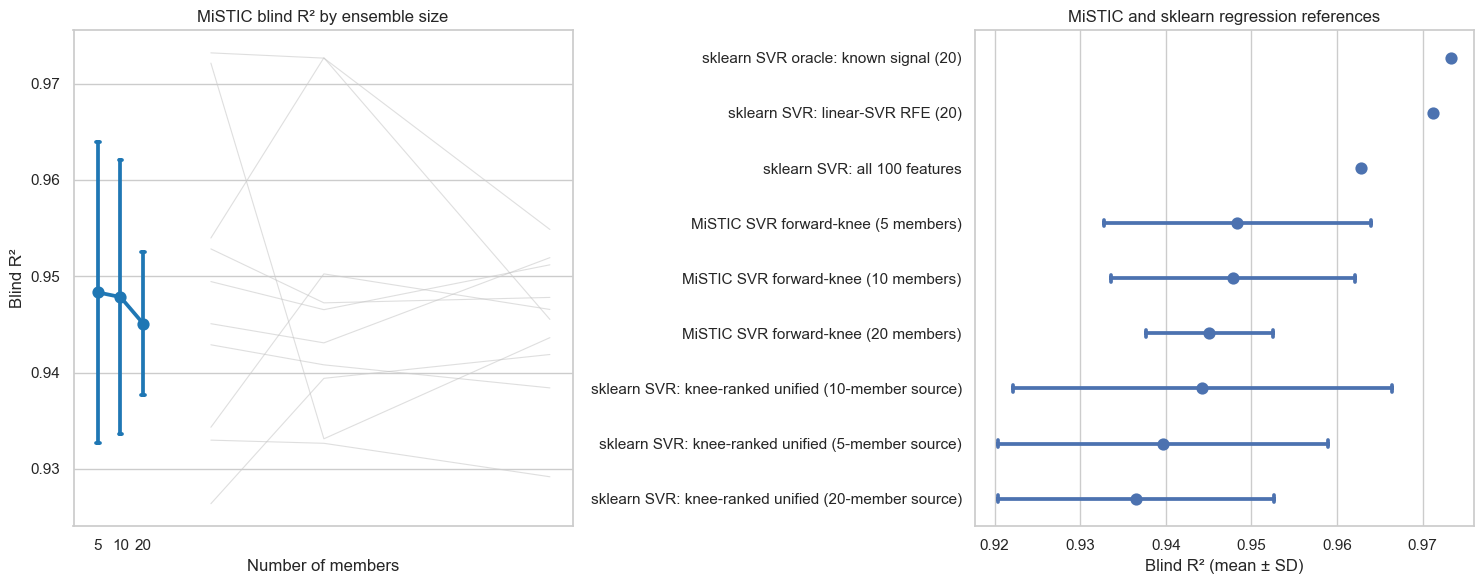

In [7]:
plot_data = results.copy()
order = plot_data.groupby("method")["r2"].mean().sort_values(ascending=False).index
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
mistic_rows = results[results["method"].str.startswith("MiSTIC")]
sns.pointplot(data=mistic_rows, x="num_models", y="r2", errorbar="sd",
              capsize=0.15, color="tab:blue", ax=axes[0])
for _, seed_data in mistic_rows.groupby("seed"):
    axes[0].plot(seed_data["num_models"], seed_data["r2"],
                 color="0.75", alpha=0.5, linewidth=0.8, zorder=0)
axes[0].set_title("MiSTIC blind R² by ensemble size")
axes[0].set_xlabel("Number of members")
axes[0].set_ylabel("Blind R²")
sns.pointplot(data=plot_data, y="method", x="r2", order=order,
              errorbar="sd", join=False, capsize=0.12, ax=axes[1])
axes[1].set_title("MiSTIC and sklearn regression references")
axes[1].set_xlabel("Blind R² (mean ± SD)")
axes[1].set_ylabel("")
plt.tight_layout()
plot_path = repo_root / "validation/Synthetic100_regression_member_count_10seeds.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()


## Interpretation notes

The ten model-building seeds all share one blind set, so their variation
measures sensitivity to inner splitting and selection rather than uncertainty
across independent test samples. The oracle is not a deployable feature
selection method; it quantifies performance when signal identities are known.
